# Loading data

In [14]:
import os, argparse, time
import matplotlib.pyplot as plt
import numpy as np
from plotting import new_figure, save_figure
from ode.utils import load_from_config
from scipy.constants import c as c_cnst
from scipy import interpolate
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm


results_dir = "results/coupling/"
geometry = "cylindrical" 
L = 0.05
R = 0.05
Ntheta = 50
Nphi = 1
modes = [
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (0, 1, 0)},
    {"mode_fam": "TE", "mode_par": "a", "mode_ind": (1, 1, 1)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (1, 1, 1)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (0, 1, 1)},
    {"mode_fam": "TE", "mode_par": "a", "mode_ind": (2, 1, 1)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (2, 1, 1)},
    {"mode_fam": "TE", "mode_par": "a", "mode_ind": (1, 1, 2)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (1, 1, 2)},
    {"mode_fam": "TM", "mode_par": "a", "mode_ind": (1, 1, 0)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (1, 1, 0)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (0, 1, 2)},
    {"mode_fam": "TM", "mode_par": "a", "mode_ind": (1, 1, 1)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (1, 1, 1)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (0, 1, 1)},
    {"mode_fam": "TE", "mode_par": "a", "mode_ind": (2, 1, 2)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (2, 1, 2)},
    {"mode_fam": "TM", "mode_par": "a", "mode_ind": (1, 1, 2)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (1, 1, 2)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (0, 1, 2)},
    {"mode_fam": "TE", "mode_par": "a", "mode_ind": (1, 1, 3)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (1, 1, 3)},
    {"mode_fam": "TM", "mode_par": "a", "mode_ind": (2, 1, 0)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (2, 1, 0)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (0, 1, 3)},
    {"mode_fam": "TM", "mode_par": "a", "mode_ind": (2, 1, 1)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (2, 1, 1)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (0, 2, 0)},
    {"mode_fam": "TE", "mode_par": "a", "mode_ind": (1, 2, 1)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (1, 2, 1)},
    {"mode_fam": "TE", "mode_par": "a", "mode_ind": (2, 1, 3)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (2, 1, 3)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (0, 2, 1)},
    {"mode_fam": "TM", "mode_par": "a", "mode_ind": (2, 1, 2)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (2, 1, 2)},
    {"mode_fam": "TM", "mode_par": "a", "mode_ind": (1, 1, 3)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (1, 1, 3)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (0, 1, 3)},
    {"mode_fam": "TE", "mode_par": "a", "mode_ind": (1, 2, 2)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (1, 2, 2)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (0, 2, 2)},
]

def mode_dir(mode):
    i, j, k = mode["mode_ind"]
    return Path(results_dir) / f"{geometry}_{mode['mode_fam']}_{i},{j},{k}"

def mode_file(mode, pol):
    i, j, k = mode["mode_ind"]
    fname = (
        f"coupling_{geometry}_pol_{pol}"
        f"_{mode['mode_fam']}_{i},{j},{k}"
        f"_L_{L}_R_{R}_Ntheta_{Ntheta}_Nphi_{Nphi}.npz"
    )
    return mode_dir(mode) / fname

# Build list of (mode, pol, path) for all existing files
dir_list = []
for mode in modes:
    for pol in ("cross", "plus"):
        path = mode_file(mode, pol)
        if path.exists():
            dir_list.append({"mode": mode, "pol": pol, "path": path})
        else:
            print(f"Missing: {path}")

data = np.load(dir_list[0]["path"])
print(list(data.keys()))  # inspect available arrays

data_strain = np.load("data/GW_M=1.00e-06_q=1.00_20260420_151640.npy", allow_pickle=True)


Missing: results/coupling/cylindrical_TE_0,1,1/coupling_cylindrical_pol_cross_TE_0,1,1_L_0.05_R_0.05_Ntheta_50_Nphi_1.npz
Missing: results/coupling/cylindrical_TE_0,1,1/coupling_cylindrical_pol_plus_TE_0,1,1_L_0.05_R_0.05_Ntheta_50_Nphi_1.npz
Missing: results/coupling/cylindrical_TE_0,1,2/coupling_cylindrical_pol_cross_TE_0,1,2_L_0.05_R_0.05_Ntheta_50_Nphi_1.npz
Missing: results/coupling/cylindrical_TE_0,1,2/coupling_cylindrical_pol_plus_TE_0,1,2_L_0.05_R_0.05_Ntheta_50_Nphi_1.npz
Missing: results/coupling/cylindrical_TE_0,1,3/coupling_cylindrical_pol_cross_TE_0,1,3_L_0.05_R_0.05_Ntheta_50_Nphi_1.npz
Missing: results/coupling/cylindrical_TE_0,1,3/coupling_cylindrical_pol_plus_TE_0,1,3_L_0.05_R_0.05_Ntheta_50_Nphi_1.npz
['cavity_type', 'mode_family', 'mode_indices', 'L', 'R', 'a', 'b', 'c', 'omega', 'pol', 'N_theta', 'N_phi', 'theta', 'phi', 'eta_a', 'eta_b', 'eta', 'C']


In [ ]:
import os
import copy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.transforms as transforms
import matplotlib.cm as cm
from pathlib import Path
from scipy.constants import mu_0

from coupling.utils import mean_calc

# ── parameters ────────────────────────────────────────────────────────────────
results_dir = "results/coupling/"
geometry    = "cylindrical"
L           = 0.05
R           = 0.05
Ntheta      = 50
Nphi        = 1

Q_l  = 1e5
B0   = 14.0          # T
V    = np.pi * R**2 * L
beta = 1.0

GW_FILE = "data/GW_M=1.00e-06_q=1.00_20260420_151640.npy"

# ── plot settings ──────────────────────────────────────────────────────────────
FIGSIZE            = (17, 9)
MARKER_SIZE        = 95
MARKER             = "s"
CMAP               = "viridis"
KEEP_EVERY         = 1
SAME_FREQ_GAP      = 1.5
DIFF_FREQ_GAP      = 2.0
FREQ_TOL_GHZ       = 0.0005
ABS_LO_PERCENTILE  = 20
ABS_HI_PERCENTILE  = 97

# ── modes ──────────────────────────────────────────────────────────────────────
modes = [
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (0, 1, 0)},
    {"mode_fam": "TE", "mode_par": "a", "mode_ind": (1, 1, 1)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (1, 1, 1)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (0, 1, 1)},
    {"mode_fam": "TE", "mode_par": "a", "mode_ind": (2, 1, 1)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (2, 1, 1)},
    {"mode_fam": "TE", "mode_par": "a", "mode_ind": (1, 1, 2)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (1, 1, 2)},
    {"mode_fam": "TM", "mode_par": "a", "mode_ind": (1, 1, 0)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (1, 1, 0)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (0, 1, 2)},
    {"mode_fam": "TM", "mode_par": "a", "mode_ind": (1, 1, 1)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (1, 1, 1)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (0, 1, 1)},
    {"mode_fam": "TE", "mode_par": "a", "mode_ind": (2, 1, 2)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (2, 1, 2)},
    {"mode_fam": "TM", "mode_par": "a", "mode_ind": (1, 1, 2)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (1, 1, 2)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (0, 1, 2)},
    {"mode_fam": "TE", "mode_par": "a", "mode_ind": (1, 1, 3)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (1, 1, 3)},
    {"mode_fam": "TM", "mode_par": "a", "mode_ind": (2, 1, 0)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (2, 1, 0)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (0, 1, 3)},
    {"mode_fam": "TM", "mode_par": "a", "mode_ind": (2, 1, 1)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (2, 1, 1)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (0, 2, 0)},
    {"mode_fam": "TE", "mode_par": "a", "mode_ind": (1, 2, 1)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (1, 2, 1)},
    {"mode_fam": "TE", "mode_par": "a", "mode_ind": (2, 1, 3)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (2, 1, 3)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (0, 2, 1)},
    {"mode_fam": "TM", "mode_par": "a", "mode_ind": (2, 1, 2)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (2, 1, 2)},
    {"mode_fam": "TM", "mode_par": "a", "mode_ind": (1, 1, 3)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (1, 1, 3)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (0, 1, 3)},
    {"mode_fam": "TE", "mode_par": "a", "mode_ind": (1, 2, 2)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (1, 2, 2)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (0, 2, 2)},
]

# ── file path helpers ──────────────────────────────────────────────────────────
def mode_file(mode, pol):
    i, j, k = mode["mode_ind"]
    fname = (
        f"coupling_{geometry}_pol_{pol}"
        f"_{mode['mode_fam']}_{i},{j},{k}"
        f"_L_{L}_R_{R}_Ntheta_{Ntheta}_Nphi_{Nphi}.npz"
    )
    folder = Path(results_dir) / f"{geometry}_{mode['mode_fam']}_{i},{j},{k}"
    return folder / fname

# ── load GW strain ─────────────────────────────────────────────────────────────
gw = np.load(GW_FILE)
t_gw    = gw[0]   # time [s]
h_plus  = gw[1]
h_cross = gw[2]

# ── load coupling data and compute P_sig(t) per mode per polarisation ──────────
def load_mode_power(mode, pol, h_strain):
    path = mode_file(mode, pol)
    if not path.exists():
        return None, None
    data   = np.load(path)
    omega  = float(data["omega"])
    theta  = data["theta"]          # (N_theta,)
    C_raw  = data["C"]              # (1, N_theta)
    mean_C = mean_calc(C_raw, theta)

    # P_sig(t) = beta/(1+beta) * omega/(2*mu0) * h(t)^2 * B0^2 * Q_l * C * V
    prefactor = (beta / (1.0 + beta)) * (omega / (2.0 * mu_0)) * B0**2 * Q_l * mean_C * V
    P_sig = prefactor * h_strain**2
    return omega, P_sig


# build dicts keyed by mode label
def mode_label(mode):
    i, j, k = mode["mode_ind"]
    return f"{mode['mode_fam']}_{mode['mode_par']}_{i},{j},{k}"


loaded_cross = {}   # label -> (omega, P_sig array)
loaded_plus  = {}

for mode in modes:
    lbl = mode_label(mode)
    omega_c, P_c = load_mode_power(mode, "cross", h_cross)
    omega_p, P_p = load_mode_power(mode, "plus",  h_plus)
    if omega_c is not None:
        loaded_cross[lbl] = {"omega": omega_c, "P": P_c}
    if omega_p is not None:
        loaded_plus[lbl]  = {"omega": omega_p, "P": P_p}

# ── plotting function ──────────────────────────────────────────────────────────
def make_power_plot(loaded_modes, t, pol_label):
    # sort by frequency
    mode_items = sorted(loaded_modes.items(), key=lambda kv: kv[1]["omega"])

    mode_names      = []
    mode_freqs      = []
    mode_y_positions = []

    prev_freq, y = None, 0.0
    for key, val in mode_items:
        freq = val["omega"] / (2 * np.pi) / 1e9
        if prev_freq is not None:
            same = abs(freq - prev_freq) < FREQ_TOL_GHZ
            y += SAME_FREQ_GAP if same else DIFF_FREQ_GAP
        mode_names.append(key)
        mode_freqs.append(freq)
        mode_y_positions.append(y)
        prev_freq = freq

    # build frequency groups for left-axis labels
    freq_groups = []
    start = 0
    for i in range(1, len(mode_freqs) + 1):
        is_break = (
            i == len(mode_freqs)
            or abs(mode_freqs[i] - mode_freqs[i - 1]) >= FREQ_TOL_GHZ
        )
        if is_break:
            y0, y1 = mode_y_positions[start], mode_y_positions[i - 1]
            freq_groups.append({
                "freq": mode_freqs[start],
                "start": start, "end": i - 1,
                "y0": y0, "y1": y1, "yc": 0.5 * (y0 + y1),
            })
            start = i

    # collect scatter data
    t_ns = t * 1e9
    all_t, all_y, all_c = [], [], []

    for (key, val), yrow in zip(mode_items, mode_y_positions):
        P = np.abs(val["P"])
        m = np.isfinite(t_ns) & np.isfinite(P)
        ts, Ps = t_ns[m][::KEEP_EVERY], P[m][::KEEP_EVERY]
        if ts.size == 0:
            continue
        all_t.append(ts)
        all_y.append(np.full(ts.shape, yrow))
        all_c.append(Ps)

    if not all_t:
        raise ValueError(f"No data to plot for polarisation {pol_label}.")

    all_t = np.concatenate(all_t)
    all_y = np.concatenate(all_y)
    all_c = np.concatenate(all_c)

    # colour normalisation
    vals = all_c[np.isfinite(all_c) & (all_c > 0)]
    vmin = max(np.percentile(vals, ABS_LO_PERCENTILE), np.min(vals))
    vmax = np.percentile(vals, ABS_HI_PERCENTILE)
    if vmax <= vmin:
        vmax = np.max(vals)
    norm = colors.LogNorm(vmin=vmin, vmax=vmax)

    all_c_plot = all_c.copy()
    all_c_plot[all_c_plot <= 0] = vmin / 10.0

    cmap_obj = copy.copy(cm.get_cmap(CMAP))
    cmap_obj.set_under(cmap_obj(0.0))

    # plot
    fig, ax = plt.subplots(figsize=FIGSIZE)
    sc = ax.scatter(
        all_t, all_y, c=all_c_plot, cmap=cmap_obj, norm=norm,
        s=MARKER_SIZE, marker=MARKER, linewidths=0
    )

    ax.set_yticks(mode_y_positions)
    ax.set_yticklabels(mode_names, fontsize=10)
    for yy in mode_y_positions:
        ax.axhline(yy, color="k", lw=0.4, alpha=0.12, zorder=0)

    ax.grid(axis="x", alpha=0.25)
    ax.set_xlabel("Time [ns]", fontsize=12)
    ax.set_title(
        rf"Signal power $P_{{\rm sig}}(t)$ — {pol_label} polarisation"
        f"\n$Q_l={Q_l:.0e}$,  $B_0={B0}$ T,  $V={V*1e6:.2f}$ cm³",
        fontsize=13
    )

    # frequency labels on far left
    trans = transforms.blended_transform_factory(ax.transAxes, ax.transData)
    x_text, x_line, x_hook = -0.16, -0.14, -0.11

    for g in freq_groups:
        ax.text(
            x_text, g["yc"], f'{g["freq"]:.2f} GHz',
            transform=trans, ha="right", va="center",
            fontsize=10, color="black", clip_on=False
        )
        if g["end"] > g["start"]:
            ax.plot([x_line, x_line], [g["y0"], g["y1"]],
                    transform=trans, color="black", lw=1.2, clip_on=False)
            ax.plot([x_line, x_hook], [g["y0"], g["y0"]],
                    transform=trans, color="black", lw=1.2, clip_on=False)
            ax.plot([x_line, x_hook], [g["y1"], g["y1"]],
                    transform=trans, color="black", lw=1.2, clip_on=False)
        else:
            ax.plot([x_line, x_hook], [g["yc"], g["yc"]],
                    transform=trans, color="black", lw=1.2, clip_on=False)

    cbar = plt.colorbar(sc, ax=ax, pad=0.02)
    cbar.set_label(r"$P_{\rm sig}$ [W]", fontsize=12)

    plt.tight_layout()
    fig.subplots_adjust(left=0.28)
    return fig


# ── generate and save both plots ───────────────────────────────────────────────
fig_cross = make_power_plot(loaded_cross, t_gw, "cross")
fig_plus  = make_power_plot(loaded_plus,  t_gw, "plus")

fig_cross.savefig("results/P_sig_cross.pdf", bbox_inches="tight")
fig_plus.savefig( "results/P_sig_plus.pdf",  bbox_inches="tight")

plt.show()
print("Done.")

Preloading coupling files...
  Missing: results/coupling/cylindrical_TE_0,1,1/coupling_cylindrical_pol_cross_TE_0,1,1_L_0.05_R_0.05_Ntheta_50_Nphi_1.npz
  Missing: results/coupling/cylindrical_TE_0,1,1/coupling_cylindrical_pol_plus_TE_0,1,1_L_0.05_R_0.05_Ntheta_50_Nphi_1.npz
  Missing: results/coupling/cylindrical_TE_0,1,2/coupling_cylindrical_pol_cross_TE_0,1,2_L_0.05_R_0.05_Ntheta_50_Nphi_1.npz
  Missing: results/coupling/cylindrical_TE_0,1,2/coupling_cylindrical_pol_plus_TE_0,1,2_L_0.05_R_0.05_Ntheta_50_Nphi_1.npz
  Missing: results/coupling/cylindrical_TE_0,1,3/coupling_cylindrical_pol_cross_TE_0,1,3_L_0.05_R_0.05_Ntheta_50_Nphi_1.npz
  Missing: results/coupling/cylindrical_TE_0,1,3/coupling_cylindrical_pol_plus_TE_0,1,3_L_0.05_R_0.05_Ntheta_50_Nphi_1.npz
  Loaded 74 files.


/var/folders/4w/tsf6hqg15s51q56dbr12bnk40000gp/T/ipykernel_27922/524183428.py:197: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = copy.copy(cm.get_cmap(CMAP))
/var/folders/4w/tsf6hqg15s51q56dbr12bnk40000gp/T/ipykernel_27922/524183428.py:197: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = copy.copy(cm.get_cmap(CMAP))


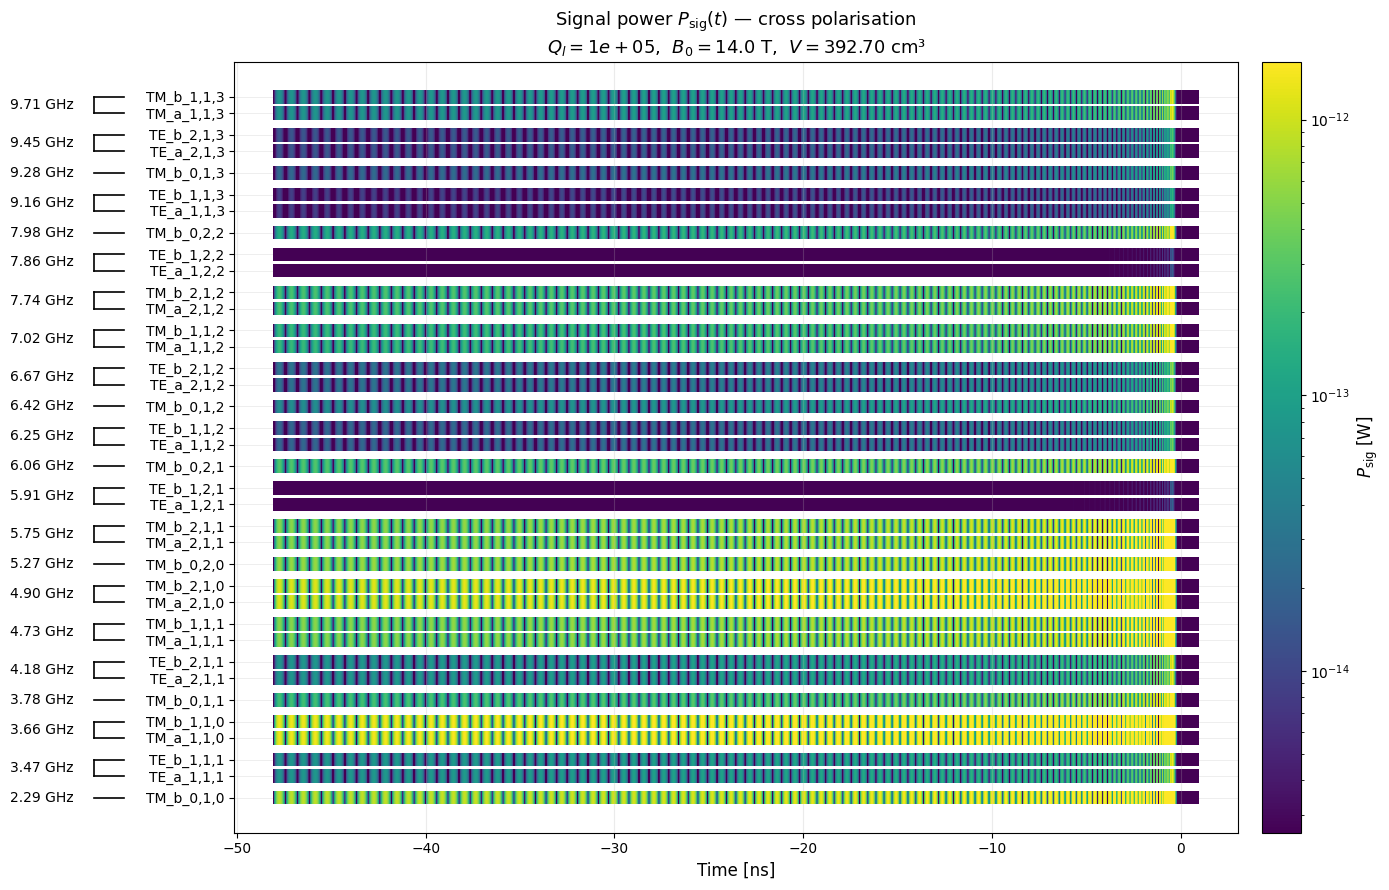

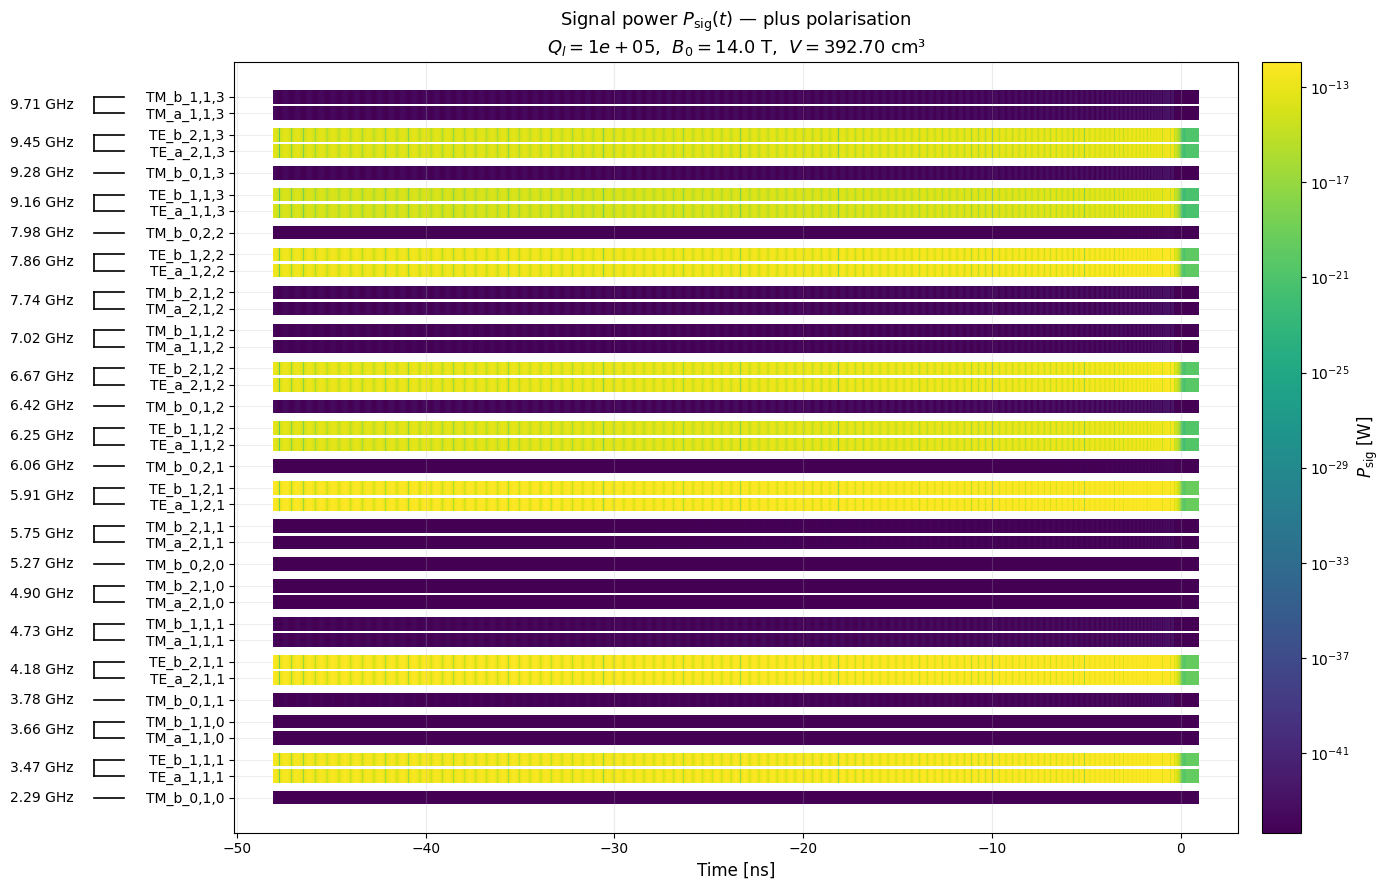

Done.


In [3]:
import copy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.transforms as transforms
import matplotlib.cm as cm
from pathlib import Path
from scipy.constants import mu_0

from coupling.utils import mean_calc

# ── parameters ────────────────────────────────────────────────────────────────
results_dir = "results/coupling/"
geometry    = "cylindrical"
L           = 0.05
R           = 0.05
Ntheta      = 50
Nphi        = 1

Q_l  = 1e5
B0   = 14.0
V    = np.pi * R**2 * L
beta = 1.0

GW_FILE = "data/GW_M=1.00e-06_q=1.00_20260420_151640.npy"

# ── plot settings ──────────────────────────────────────────────────────────────
FIGSIZE           = (17, 9)
MARKER_SIZE       = 95
MARKER            = "s"
CMAP              = "viridis"
KEEP_EVERY        = 1
SAME_FREQ_GAP     = 1.5
DIFF_FREQ_GAP     = 2.0
FREQ_TOL_GHZ      = 0.0005
ABS_LO_PERCENTILE = 20
ABS_HI_PERCENTILE = 97

# ── modes ──────────────────────────────────────────────────────────────────────
modes = [
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (0, 1, 0)},
    {"mode_fam": "TE", "mode_par": "a", "mode_ind": (1, 1, 1)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (1, 1, 1)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (0, 1, 1)},
    {"mode_fam": "TE", "mode_par": "a", "mode_ind": (2, 1, 1)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (2, 1, 1)},
    {"mode_fam": "TE", "mode_par": "a", "mode_ind": (1, 1, 2)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (1, 1, 2)},
    {"mode_fam": "TM", "mode_par": "a", "mode_ind": (1, 1, 0)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (1, 1, 0)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (0, 1, 2)},
    {"mode_fam": "TM", "mode_par": "a", "mode_ind": (1, 1, 1)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (1, 1, 1)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (0, 1, 1)},
    {"mode_fam": "TE", "mode_par": "a", "mode_ind": (2, 1, 2)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (2, 1, 2)},
    {"mode_fam": "TM", "mode_par": "a", "mode_ind": (1, 1, 2)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (1, 1, 2)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (0, 1, 2)},
    {"mode_fam": "TE", "mode_par": "a", "mode_ind": (1, 1, 3)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (1, 1, 3)},
    {"mode_fam": "TM", "mode_par": "a", "mode_ind": (2, 1, 0)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (2, 1, 0)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (0, 1, 3)},
    {"mode_fam": "TM", "mode_par": "a", "mode_ind": (2, 1, 1)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (2, 1, 1)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (0, 2, 0)},
    {"mode_fam": "TE", "mode_par": "a", "mode_ind": (1, 2, 1)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (1, 2, 1)},
    {"mode_fam": "TE", "mode_par": "a", "mode_ind": (2, 1, 3)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (2, 1, 3)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (0, 2, 1)},
    {"mode_fam": "TM", "mode_par": "a", "mode_ind": (2, 1, 2)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (2, 1, 2)},
    {"mode_fam": "TM", "mode_par": "a", "mode_ind": (1, 1, 3)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (1, 1, 3)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (0, 1, 3)},
    {"mode_fam": "TE", "mode_par": "a", "mode_ind": (1, 2, 2)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (1, 2, 2)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (0, 2, 2)},
]

# ── helpers ────────────────────────────────────────────────────────────────────
def mode_label(mode):
    i, j, k = mode["mode_ind"]
    return f"{mode['mode_fam']}_{mode['mode_par']}_{i},{j},{k}"

def mode_file(mode, pol):
    i, j, k = mode["mode_ind"]
    fname = (
        f"coupling_{geometry}_pol_{pol}"
        f"_{mode['mode_fam']}_{i},{j},{k}"
        f"_L_{L}_R_{R}_Ntheta_{Ntheta}_Nphi_{Nphi}.npz"
    )
    folder = Path(results_dir) / f"{geometry}_{mode['mode_fam']}_{i},{j},{k}"
    return folder / fname

# ── load GW strain ─────────────────────────────────────────────────────────────
gw      = np.load(GW_FILE)
t_gw    = gw[0]
h_plus  = gw[1]
h_cross = gw[2]

# ── preload all coupling files → cache omega + mean_C ─────────────────────────
# Single pass: all disk I/O and mean_calc happen here only once.
print("Preloading coupling files...")
cache = {}  # (label, pol) -> {"omega": float, "mean_C": float}

for mode in modes:
    lbl = mode_label(mode)
    for pol in ("cross", "plus"):
        path = mode_file(mode, pol)
        if not path.exists():
            print(f"  Missing: {path}")
            continue
        data   = np.load(path)
        omega  = float(data["omega"])
        theta  = data["theta"]
        C_raw  = data["C"]
        mean_C = mean_calc(C_raw, theta)
        cache[(lbl, pol)] = {"omega": omega, "mean_C": float(mean_C)}

print(f"  Loaded {len(cache)} files.")

# ── compute P_sig(t) — scalar prefactor × h(t)^2, instant ────────────────────
loaded_cross = {}
loaded_plus  = {}

for mode in modes:
    lbl = mode_label(mode)

    if (lbl, "cross") in cache:
        e  = cache[(lbl, "cross")]
        pf = (beta / (1.0 + beta)) * (e["omega"] / (2.0 * mu_0)) * B0**2 * Q_l * e["mean_C"] * V
        loaded_cross[lbl] = {"omega": e["omega"], "P": pf * h_cross**2}

    if (lbl, "plus") in cache:
        e  = cache[(lbl, "plus")]
        pf = (beta / (1.0 + beta)) * (e["omega"] / (2.0 * mu_0)) * B0**2 * Q_l * e["mean_C"] * V
        loaded_plus[lbl]  = {"omega": e["omega"], "P": pf * h_plus**2}

# ── plotting ───────────────────────────────────────────────────────────────────
def make_power_plot(loaded_modes, t, pol_label):
    mode_items = sorted(loaded_modes.items(), key=lambda kv: kv[1]["omega"])

    mode_names, mode_freqs, mode_y_positions = [], [], []
    prev_freq, y = None, 0.0
    for key, val in mode_items:
        freq = val["omega"] / (2 * np.pi) / 1e9
        if prev_freq is not None:
            y += SAME_FREQ_GAP if abs(freq - prev_freq) < FREQ_TOL_GHZ else DIFF_FREQ_GAP
        mode_names.append(key)
        mode_freqs.append(freq)
        mode_y_positions.append(y)
        prev_freq = freq

    # frequency bracket groups
    freq_groups, start = [], 0
    for i in range(1, len(mode_freqs) + 1):
        is_break = i == len(mode_freqs) or abs(mode_freqs[i] - mode_freqs[i - 1]) >= FREQ_TOL_GHZ
        if is_break:
            y0, y1 = mode_y_positions[start], mode_y_positions[i - 1]
            freq_groups.append({"freq": mode_freqs[start], "start": start, "end": i - 1,
                                 "y0": y0, "y1": y1, "yc": 0.5 * (y0 + y1)})
            start = i

    # scatter data
    t_ns = t * 1e9
    all_t, all_y, all_c = [], [], []
    for (key, val), yrow in zip(mode_items, mode_y_positions):
        P = np.abs(val["P"])
        m = np.isfinite(t_ns) & np.isfinite(P)
        ts, Ps = t_ns[m][::KEEP_EVERY], P[m][::KEEP_EVERY]
        if ts.size == 0:
            continue
        all_t.append(ts)
        all_y.append(np.full(ts.shape, yrow))
        all_c.append(Ps)

    if not all_t:
        raise ValueError(f"No data to plot for polarisation {pol_label}.")

    all_t = np.concatenate(all_t)
    all_y = np.concatenate(all_y)
    all_c = np.concatenate(all_c)

    vals = all_c[np.isfinite(all_c) & (all_c > 0)]
    vmin = max(np.percentile(vals, ABS_LO_PERCENTILE), np.min(vals))
    vmax = np.percentile(vals, ABS_HI_PERCENTILE)
    if vmax <= vmin:
        vmax = np.max(vals)
    norm = colors.LogNorm(vmin=vmin, vmax=vmax)

    all_c_plot = all_c.copy()
    all_c_plot[all_c_plot <= 0] = vmin / 10.0

    cmap_obj = copy.copy(cm.get_cmap(CMAP))
    cmap_obj.set_under(cmap_obj(0.0))

    fig, ax = plt.subplots(figsize=FIGSIZE)
    sc = ax.scatter(all_t, all_y, c=all_c_plot, cmap=cmap_obj, norm=norm,
                    s=MARKER_SIZE, marker=MARKER, linewidths=0)

    ax.set_yticks(mode_y_positions)
    ax.set_yticklabels(mode_names, fontsize=10)
    for yy in mode_y_positions:
        ax.axhline(yy, color="k", lw=0.4, alpha=0.12, zorder=0)

    ax.grid(axis="x", alpha=0.25)
    ax.set_xlabel("Time [ns]", fontsize=12)
    ax.set_title(
        rf"Signal power $P_{{\rm sig}}(t)$ — {pol_label} polarisation"
        f"\n$Q_l={Q_l:.0e}$,  $B_0={B0}$ T,  $V={V*1e6:.2f}$ cm³",
        fontsize=13
    )

    trans = transforms.blended_transform_factory(ax.transAxes, ax.transData)
    x_text, x_line, x_hook = -0.16, -0.14, -0.11
    for g in freq_groups:
        ax.text(x_text, g["yc"], f'{g["freq"]:.2f} GHz',
                transform=trans, ha="right", va="center",
                fontsize=10, color="black", clip_on=False)
        if g["end"] > g["start"]:
            ax.plot([x_line, x_line], [g["y0"], g["y1"]],
                    transform=trans, color="black", lw=1.2, clip_on=False)
            ax.plot([x_line, x_hook], [g["y0"], g["y0"]],
                    transform=trans, color="black", lw=1.2, clip_on=False)
            ax.plot([x_line, x_hook], [g["y1"], g["y1"]],
                    transform=trans, color="black", lw=1.2, clip_on=False)
        else:
            ax.plot([x_line, x_hook], [g["yc"], g["yc"]],
                    transform=trans, color="black", lw=1.2, clip_on=False)

    cbar = plt.colorbar(sc, ax=ax, pad=0.02)
    cbar.set_label(r"$P_{\rm sig}$ [W]", fontsize=12)
    plt.tight_layout()
    fig.subplots_adjust(left=0.28)
    return fig


# ── generate and save ──────────────────────────────────────────────────────────
fig_cross = make_power_plot(loaded_cross, t_gw, "cross")
fig_plus  = make_power_plot(loaded_plus,  t_gw, "plus")

fig_cross.savefig("results/P_sig_cross.pdf", bbox_inches="tight")
fig_plus.savefig( "results/P_sig_plus.pdf",  bbox_inches="tight")

plt.show()
print("Done.")

Preloading coupling files...
  Missing: results/coupling/cylindrical_TE_0,1,1/coupling_cylindrical_pol_cross_TE_0,1,1_L_0.05_R_0.05_Ntheta_50_Nphi_1.npz
  Missing: results/coupling/cylindrical_TE_0,1,1/coupling_cylindrical_pol_plus_TE_0,1,1_L_0.05_R_0.05_Ntheta_50_Nphi_1.npz
  Missing: results/coupling/cylindrical_TE_0,1,2/coupling_cylindrical_pol_cross_TE_0,1,2_L_0.05_R_0.05_Ntheta_50_Nphi_1.npz
  Missing: results/coupling/cylindrical_TE_0,1,2/coupling_cylindrical_pol_plus_TE_0,1,2_L_0.05_R_0.05_Ntheta_50_Nphi_1.npz
  Missing: results/coupling/cylindrical_TE_0,1,3/coupling_cylindrical_pol_cross_TE_0,1,3_L_0.05_R_0.05_Ntheta_50_Nphi_1.npz
  Missing: results/coupling/cylindrical_TE_0,1,3/coupling_cylindrical_pol_plus_TE_0,1,3_L_0.05_R_0.05_Ntheta_50_Nphi_1.npz
  Loaded 74 files.


/var/folders/4w/tsf6hqg15s51q56dbr12bnk40000gp/T/ipykernel_27922/2178917192.py:198: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = copy.copy(cm.get_cmap(CMAP))
/var/folders/4w/tsf6hqg15s51q56dbr12bnk40000gp/T/ipykernel_27922/2178917192.py:198: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = copy.copy(cm.get_cmap(CMAP))


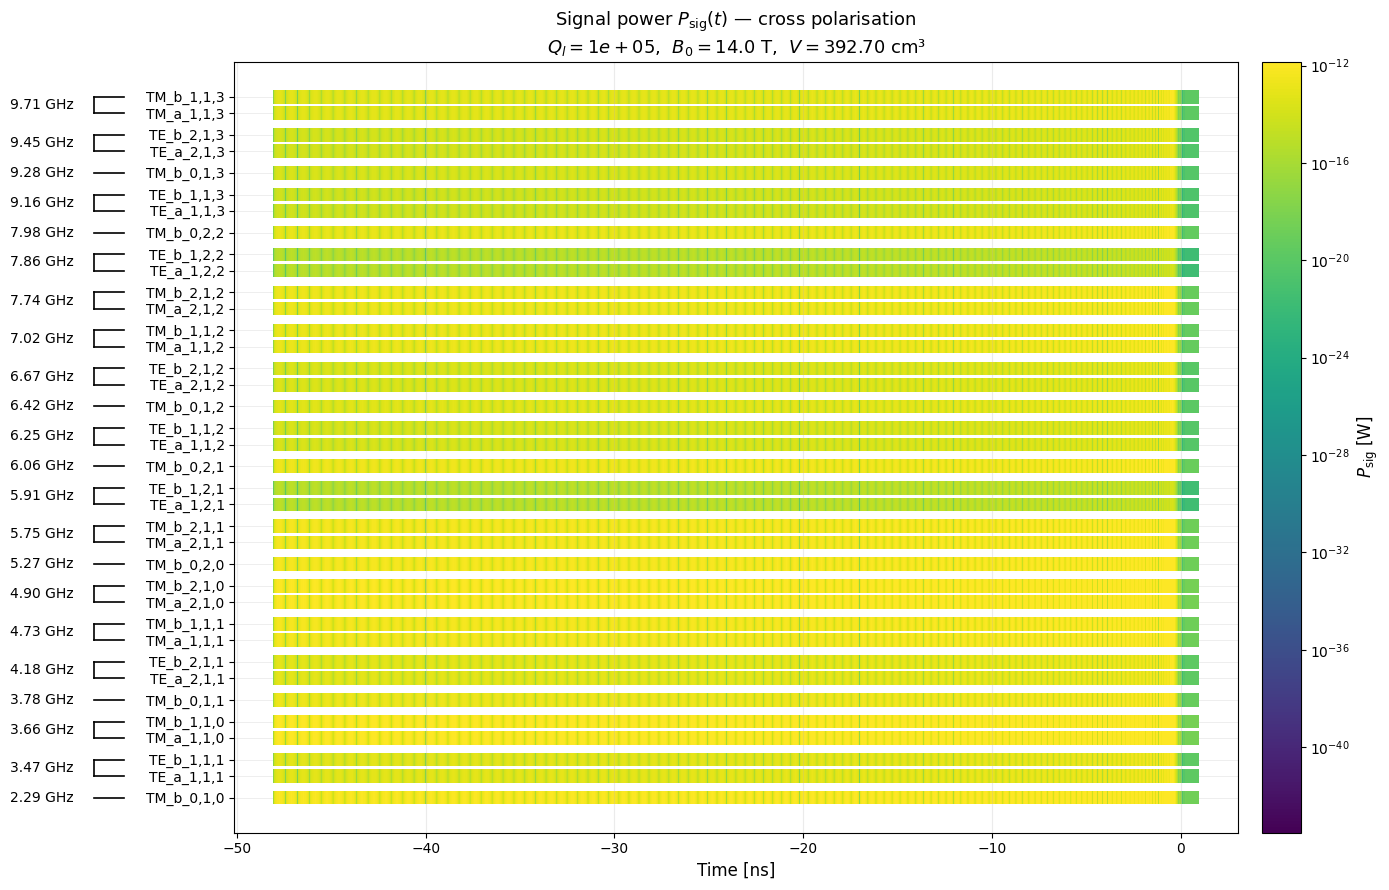

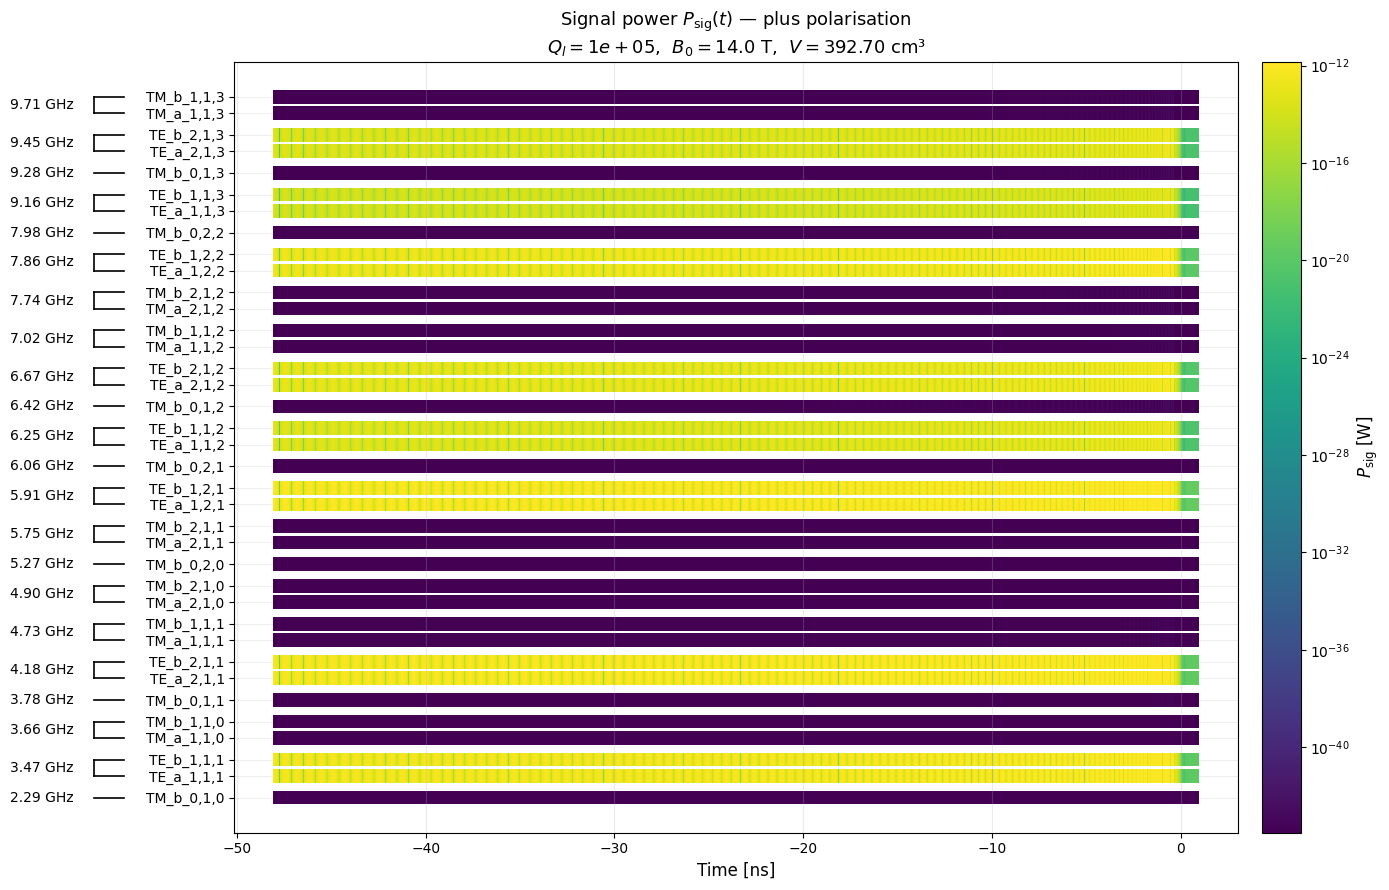

Done.


In [4]:
import copy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.transforms as transforms
import matplotlib.cm as cm
from pathlib import Path
from scipy.constants import mu_0

from coupling.utils import mean_calc

# ── parameters ────────────────────────────────────────────────────────────────
results_dir = "results/coupling/"
geometry    = "cylindrical"
L           = 0.05
R           = 0.05
Ntheta      = 50
Nphi        = 1

Q_l  = 1e5
B0   = 14.0
V    = np.pi * R**2 * L
beta = 1.0

GW_FILE = "data/GW_M=1.00e-06_q=1.00_20260420_151640.npy"

# ── plot settings ──────────────────────────────────────────────────────────────
FIGSIZE           = (17, 9)
MARKER_SIZE       = 95
MARKER            = "s"
CMAP              = "viridis"
KEEP_EVERY        = 1
SAME_FREQ_GAP     = 1.5
DIFF_FREQ_GAP     = 2.0
FREQ_TOL_GHZ      = 0.0005
ABS_LO_PERCENTILE = 20
ABS_HI_PERCENTILE = 97

# ── modes ──────────────────────────────────────────────────────────────────────
modes = [
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (0, 1, 0)},
    {"mode_fam": "TE", "mode_par": "a", "mode_ind": (1, 1, 1)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (1, 1, 1)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (0, 1, 1)},
    {"mode_fam": "TE", "mode_par": "a", "mode_ind": (2, 1, 1)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (2, 1, 1)},
    {"mode_fam": "TE", "mode_par": "a", "mode_ind": (1, 1, 2)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (1, 1, 2)},
    {"mode_fam": "TM", "mode_par": "a", "mode_ind": (1, 1, 0)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (1, 1, 0)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (0, 1, 2)},
    {"mode_fam": "TM", "mode_par": "a", "mode_ind": (1, 1, 1)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (1, 1, 1)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (0, 1, 1)},
    {"mode_fam": "TE", "mode_par": "a", "mode_ind": (2, 1, 2)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (2, 1, 2)},
    {"mode_fam": "TM", "mode_par": "a", "mode_ind": (1, 1, 2)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (1, 1, 2)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (0, 1, 2)},
    {"mode_fam": "TE", "mode_par": "a", "mode_ind": (1, 1, 3)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (1, 1, 3)},
    {"mode_fam": "TM", "mode_par": "a", "mode_ind": (2, 1, 0)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (2, 1, 0)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (0, 1, 3)},
    {"mode_fam": "TM", "mode_par": "a", "mode_ind": (2, 1, 1)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (2, 1, 1)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (0, 2, 0)},
    {"mode_fam": "TE", "mode_par": "a", "mode_ind": (1, 2, 1)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (1, 2, 1)},
    {"mode_fam": "TE", "mode_par": "a", "mode_ind": (2, 1, 3)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (2, 1, 3)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (0, 2, 1)},
    {"mode_fam": "TM", "mode_par": "a", "mode_ind": (2, 1, 2)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (2, 1, 2)},
    {"mode_fam": "TM", "mode_par": "a", "mode_ind": (1, 1, 3)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (1, 1, 3)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (0, 1, 3)},
    {"mode_fam": "TE", "mode_par": "a", "mode_ind": (1, 2, 2)},
    {"mode_fam": "TE", "mode_par": "b", "mode_ind": (1, 2, 2)},
    {"mode_fam": "TM", "mode_par": "b", "mode_ind": (0, 2, 2)},
]

# ── helpers ────────────────────────────────────────────────────────────────────
def mode_label(mode):
    i, j, k = mode["mode_ind"]
    return f"{mode['mode_fam']}_{mode['mode_par']}_{i},{j},{k}"

def mode_file(mode, pol):
    i, j, k = mode["mode_ind"]
    fname = (
        f"coupling_{geometry}_pol_{pol}"
        f"_{mode['mode_fam']}_{i},{j},{k}"
        f"_L_{L}_R_{R}_Ntheta_{Ntheta}_Nphi_{Nphi}.npz"
    )
    folder = Path(results_dir) / f"{geometry}_{mode['mode_fam']}_{i},{j},{k}"
    return folder / fname

# ── load GW strain ─────────────────────────────────────────────────────────────
gw      = np.load(GW_FILE)
t_gw    = gw[0]
h_plus  = gw[1]
h_cross = gw[2]

# ── preload all coupling files → cache omega + mean_C ─────────────────────────
# Single pass: all disk I/O and mean_calc happen here only once.
print("Preloading coupling files...")
cache = {}  # (label, pol) -> {"omega": float, "mean_C": float}

for mode in modes:
    lbl = mode_label(mode)
    for pol in ("cross", "plus"):
        path = mode_file(mode, pol)
        if not path.exists():
            print(f"  Missing: {path}")
            continue
        data   = np.load(path)
        omega  = float(data["omega"])
        theta  = data["theta"]
        C_raw  = data["C"]
        mean_C = mean_calc(C_raw, theta)
        cache[(lbl, pol)] = {"omega": omega, "mean_C": float(mean_C)}

print(f"  Loaded {len(cache)} files.")

# ── compute P_sig(t) — scalar prefactor × h(t)^2, instant ────────────────────
loaded_cross = {}
loaded_plus  = {}

for mode in modes:
    lbl = mode_label(mode)

    if (lbl, "cross") in cache:
        e  = cache[(lbl, "cross")]
        pf = (beta / (1.0 + beta)) * (e["omega"] / (2.0 * mu_0)) * B0**2 * Q_l * e["mean_C"] * V
        loaded_cross[lbl] = {"omega": e["omega"], "P": pf * h_cross**2}

    if (lbl, "plus") in cache:
        e  = cache[(lbl, "plus")]
        pf = (beta / (1.0 + beta)) * (e["omega"] / (2.0 * mu_0)) * B0**2 * Q_l * e["mean_C"] * V
        loaded_plus[lbl]  = {"omega": e["omega"], "P": pf * h_plus**2}

# ── plotting ───────────────────────────────────────────────────────────────────
def make_power_plot(loaded_modes, t, pol_label, norm=None):
    mode_items = sorted(loaded_modes.items(), key=lambda kv: kv[1]["omega"])

    mode_names, mode_freqs, mode_y_positions = [], [], []
    prev_freq, y = None, 0.0
    for key, val in mode_items:
        freq = val["omega"] / (2 * np.pi) / 1e9
        if prev_freq is not None:
            y += SAME_FREQ_GAP if abs(freq - prev_freq) < FREQ_TOL_GHZ else DIFF_FREQ_GAP
        mode_names.append(key)
        mode_freqs.append(freq)
        mode_y_positions.append(y)
        prev_freq = freq

    # frequency bracket groups
    freq_groups, start = [], 0
    for i in range(1, len(mode_freqs) + 1):
        is_break = i == len(mode_freqs) or abs(mode_freqs[i] - mode_freqs[i - 1]) >= FREQ_TOL_GHZ
        if is_break:
            y0, y1 = mode_y_positions[start], mode_y_positions[i - 1]
            freq_groups.append({"freq": mode_freqs[start], "start": start, "end": i - 1,
                                 "y0": y0, "y1": y1, "yc": 0.5 * (y0 + y1)})
            start = i

    # scatter data
    t_ns = t * 1e9
    all_t, all_y, all_c = [], [], []
    for (key, val), yrow in zip(mode_items, mode_y_positions):
        P = np.abs(val["P"])
        m = np.isfinite(t_ns) & np.isfinite(P)
        ts, Ps = t_ns[m][::KEEP_EVERY], P[m][::KEEP_EVERY]
        if ts.size == 0:
            continue
        all_t.append(ts)
        all_y.append(np.full(ts.shape, yrow))
        all_c.append(Ps)

    if not all_t:
        raise ValueError(f"No data to plot for polarisation {pol_label}.")

    all_t = np.concatenate(all_t)
    all_y = np.concatenate(all_y)
    all_c = np.concatenate(all_c)

    if norm is None:
        vals = all_c[np.isfinite(all_c) & (all_c > 0)]
        vmin = max(np.percentile(vals, ABS_LO_PERCENTILE), np.min(vals))
        vmax = np.percentile(vals, ABS_HI_PERCENTILE)
        if vmax <= vmin:
            vmax = np.max(vals)
        norm = colors.LogNorm(vmin=vmin, vmax=vmax)

    all_c_plot = all_c.copy()
    all_c_plot[all_c_plot <= 0] = norm.vmin / 10.0

    cmap_obj = copy.copy(cm.get_cmap(CMAP))
    cmap_obj.set_under(cmap_obj(0.0))

    fig, ax = plt.subplots(figsize=FIGSIZE)
    sc = ax.scatter(all_t, all_y, c=all_c_plot, cmap=cmap_obj, norm=norm,
                    s=MARKER_SIZE, marker=MARKER, linewidths=0)

    ax.set_yticks(mode_y_positions)
    ax.set_yticklabels(mode_names, fontsize=10)
    for yy in mode_y_positions:
        ax.axhline(yy, color="k", lw=0.4, alpha=0.12, zorder=0)

    ax.grid(axis="x", alpha=0.25)
    ax.set_xlabel("Time [ns]", fontsize=12)
    ax.set_title(
        rf"Signal power $P_{{\rm sig}}(t)$ — {pol_label} polarisation"
        f"\n$Q_l={Q_l:.0e}$,  $B_0={B0}$ T,  $V={V*1e6:.2f}$ cm³",
        fontsize=13
    )

    trans = transforms.blended_transform_factory(ax.transAxes, ax.transData)
    x_text, x_line, x_hook = -0.16, -0.14, -0.11
    for g in freq_groups:
        ax.text(x_text, g["yc"], f'{g["freq"]:.2f} GHz',
                transform=trans, ha="right", va="center",
                fontsize=10, color="black", clip_on=False)
        if g["end"] > g["start"]:
            ax.plot([x_line, x_line], [g["y0"], g["y1"]],
                    transform=trans, color="black", lw=1.2, clip_on=False)
            ax.plot([x_line, x_hook], [g["y0"], g["y0"]],
                    transform=trans, color="black", lw=1.2, clip_on=False)
            ax.plot([x_line, x_hook], [g["y1"], g["y1"]],
                    transform=trans, color="black", lw=1.2, clip_on=False)
        else:
            ax.plot([x_line, x_hook], [g["yc"], g["yc"]],
                    transform=trans, color="black", lw=1.2, clip_on=False)

    cbar = plt.colorbar(sc, ax=ax, pad=0.02)
    cbar.set_label(r"$P_{\rm sig}$ [W]", fontsize=12)
    plt.tight_layout()
    fig.subplots_adjust(left=0.28)
    return fig


# ── compute shared norm across both polarisations ─────────────────────────────
def collect_vals(loaded_modes):
    return np.concatenate([
        np.abs(val["P"])[np.isfinite(np.abs(val["P"])) & (np.abs(val["P"]) > 0)]
        for val in loaded_modes.values()
    ])

all_vals = np.concatenate([collect_vals(loaded_cross), collect_vals(loaded_plus)])
vmin_shared = max(np.percentile(all_vals, ABS_LO_PERCENTILE), np.min(all_vals))
vmax_shared = np.percentile(all_vals, ABS_HI_PERCENTILE)
if vmax_shared <= vmin_shared:
    vmax_shared = np.max(all_vals)
shared_norm = colors.LogNorm(vmin=vmin_shared, vmax=vmax_shared)

# ── generate and save ──────────────────────────────────────────────────────────
fig_cross = make_power_plot(loaded_cross, t_gw, "cross", norm=shared_norm)
fig_plus  = make_power_plot(loaded_plus,  t_gw, "plus",  norm=shared_norm)

fig_cross.savefig("results/P_sig_cross.pdf", bbox_inches="tight")
fig_plus.savefig( "results/P_sig_plus.pdf",  bbox_inches="tight")

plt.show()
print("Done.")